In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [5]:
df = pd.read_csv('cancer_detection_logistic_regression.csv')
target_col = "cancer_detected"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Shape: (260, 4)
Target distribution:
 cancer_detected
0    169
1     91
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

In [8]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 5, 10],
    "logreg__class_weight": [None, "balanced"],
    "logreg__solver": ["lbfgs", "liblinear"],
    "logreg__penalty": ["l2"],  # keep it simple
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV Accuracy:", grid.best_score_)
print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_


Best CV Accuracy: 0.6491289198606273
Best Params: {'logreg__C': 0.01, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}


In [9]:
y_pred_default = best_model.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print("\nTest Accuracy (threshold=0.5):", acc_default)

print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred_default))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))


Test Accuracy (threshold=0.5): 0.6538461538461539

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        34
           1       0.00      0.00      0.00        18

    accuracy                           0.65        52
   macro avg       0.33      0.50      0.40        52
weighted avg       0.43      0.65      0.52        52

Confusion Matrix:
[[34  0]
 [18  0]]


c:\Users\MAQBOOL RAASI\anacond\envs\ds_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MAQBOOL RAASI\anacond\envs\ds_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MAQBOOL RAASI\anacond\envs\ds_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

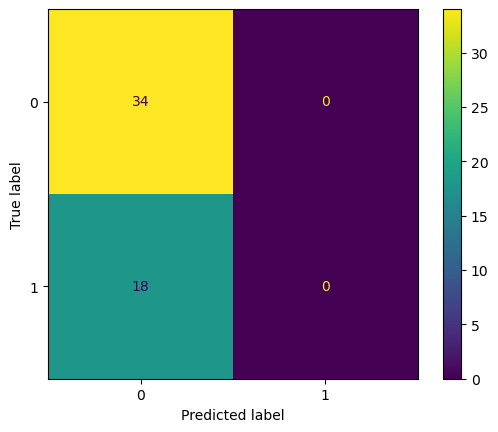

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default)
plt.show()
